# Case Study 1 : Data Mining in Financial Data

In [1]:
!pip install yfinance pandas matplotlib seaborn scikit-learn


In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


In [3]:
# --- User choices: edit these two lines ---
TICKERS = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']   # pick any 5+ tickers
TARGET_TICKER = 'AAPL'                                 # the one you'll model later

import pandas as pd
import yfinance as yf

# Download 5 years of daily prices
# auto_adjust=True gives split/dividend-adjusted prices (cleaner for return calc)
raw = yf.download(TICKERS, period="5y", auto_adjust=True)

# Use the Close prices (yfinance returns 'Close' when auto_adjust=True)
if 'Close' in raw:
    prices = raw['Close'].copy()
else:
    prices = raw['Adj Close'].copy()  # fallback

print("Preview:")
display(prices.head())

# Quick quality checks
print("\nShape:", prices.shape)
print("Date range:", prices.index.min().date(), "→", prices.index.max().date())
print("\nMissing values per column:")
print(prices.isna().sum())

# Basic cleaning: forward-fill then drop any remaining NA rows
prices = prices.ffill().dropna(how='any')

# Save a copy (optional, useful for reference)
prices.to_csv("prices_5y_clean.csv")
print("\nSaved to prices_5y_clean.csv")


[*********************100%***********************]  5 of 5 completed


Preview:


Ticker,AAPL,AMZN,GOOGL,MSFT,TSLA
Date,,,,,
2020-09-04,117.659943,164.731003,78.589172,205.428345,139.440002
2020-09-08,109.742020,157.492004,75.725845,194.315567,110.070000
2020-09-09,114.119255,163.430496,76.900307,202.590225,122.093330
2020-09-10,110.393738,158.755493,75.847610,196.913971,123.779999
2020-09-11,108.944389,155.811005,75.336182,195.629135,124.239998



Shape: (1255, 5)
Date range: 2020-09-04 → 2025-09-04

Missing values per column:
Ticker
AAPL     0
AMZN     0
GOOGL    0
MSFT     0
TSLA     0
dtype: int64

Saved to prices_5y_clean.csv


In [4]:


# Daily returns
daily_returns = prices.pct_change().dropna()

# Weekly returns (using resample)
weekly_prices = prices.resample('W').last()
weekly_returns = weekly_prices.pct_change().dropna()

# Monthly returns
monthly_prices = prices.resample('M').last()
monthly_returns = monthly_prices.pct_change().dropna()

# Preview
print("Daily returns sample:\n", daily_returns.head())
print("\nWeekly returns sample:\n", weekly_returns.head())
print("\nMonthly returns sample:\n", monthly_returns.head())


Daily returns sample:
 Ticker          AAPL      AMZN     GOOGL      MSFT      TSLA
Date                                                        
2020-09-08 -0.067295 -0.043944 -0.036434 -0.054096 -0.210628
2020-09-09  0.039887  0.037707  0.015509  0.042584  0.109233
2020-09-10 -0.032646 -0.028605 -0.013689 -0.028018  0.013815
2020-09-11 -0.013129 -0.018547 -0.006743 -0.006525  0.003716
2020-09-14  0.030000 -0.004252 -0.004572  0.006764  0.125832

Weekly returns sample:
 Ticker          AAPL      AMZN     GOOGL      MSFT      TSLA
Date                                                        
2020-09-13 -0.074074 -0.054149 -0.041392 -0.047701 -0.109007
2020-09-20 -0.046071 -0.051765 -0.042665 -0.017840  0.186279
2020-09-27  0.050917  0.047453 -0.008290  0.037078 -0.078729
2020-10-04  0.006591  0.009651  0.011494 -0.007843  0.019026
2020-10-11  0.034950  0.051728  0.037682  0.046656  0.045556

Monthly returns sample:
 Ticker          AAPL      AMZN     GOOGL      MSFT      TSLA
Date       

/tmp/ipython-input-3650214235.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_prices = prices.resample('M').last()


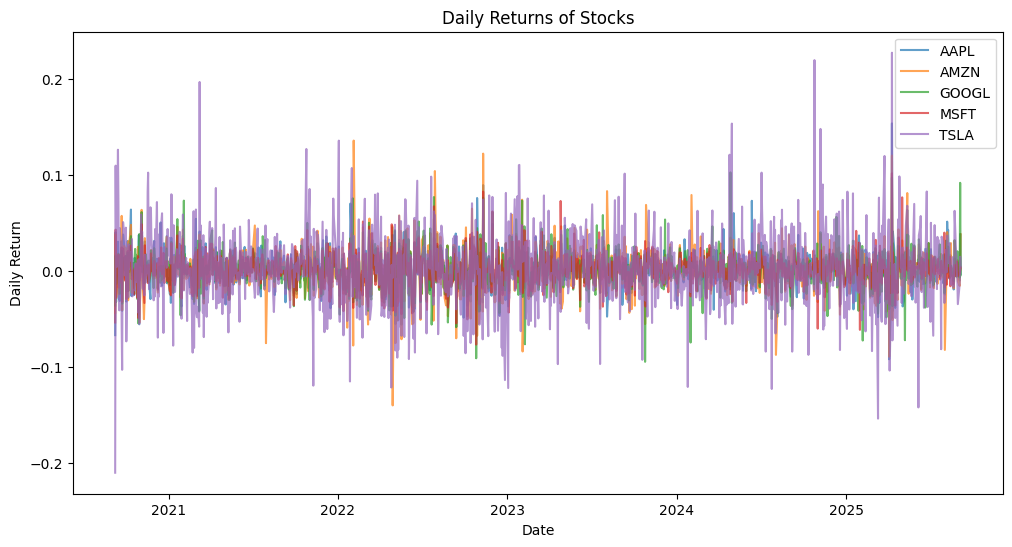

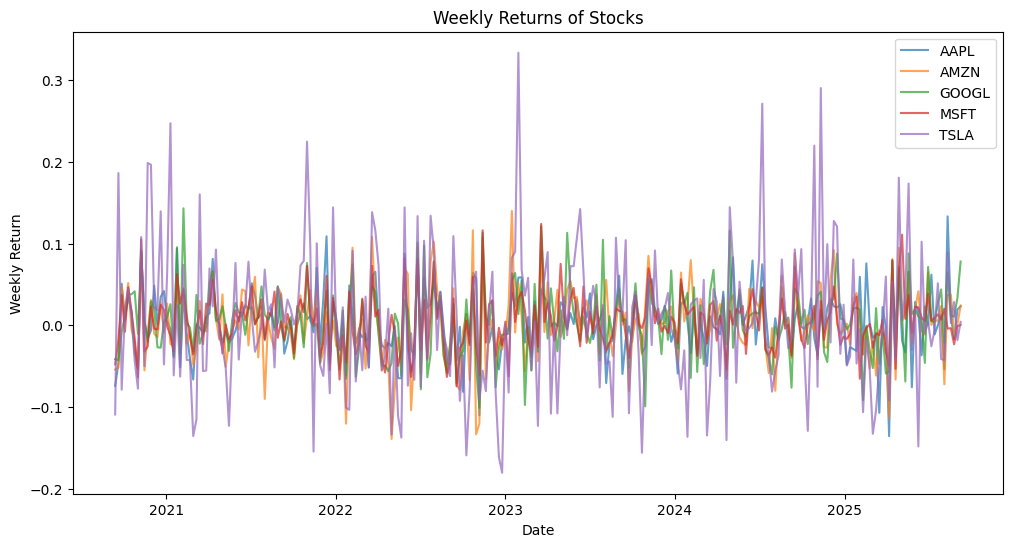

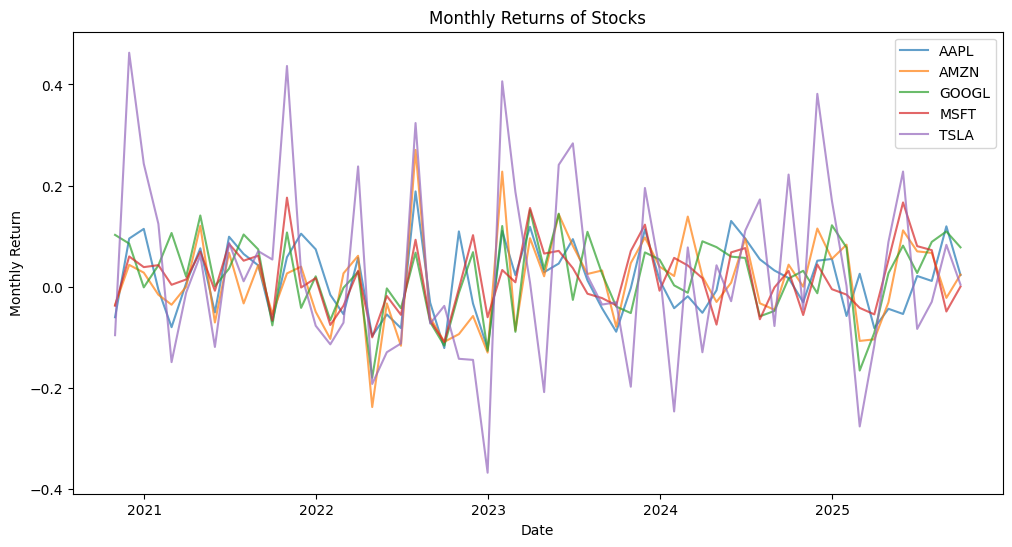

In [5]:

import matplotlib.pyplot as plt

# Daily returns plot
plt.figure(figsize=(12,6))
for ticker in daily_returns.columns:
    plt.plot(daily_returns.index, daily_returns[ticker], label=ticker, alpha=0.7)
plt.title("Daily Returns of Stocks")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.legend()
plt.show()

# Weekly returns plot
plt.figure(figsize=(12,6))
for ticker in weekly_returns.columns:
    plt.plot(weekly_returns.index, weekly_returns[ticker], label=ticker, alpha=0.7)
plt.title("Weekly Returns of Stocks")
plt.xlabel("Date")
plt.ylabel("Weekly Return")
plt.legend()
plt.show()

# Monthly returns plot
plt.figure(figsize=(12,6))
for ticker in monthly_returns.columns:
    plt.plot(monthly_returns.index, monthly_returns[ticker], label=ticker, alpha=0.7)
plt.title("Monthly Returns of Stocks")
plt.xlabel("Date")
plt.ylabel("Monthly Return")
plt.legend()
plt.show()


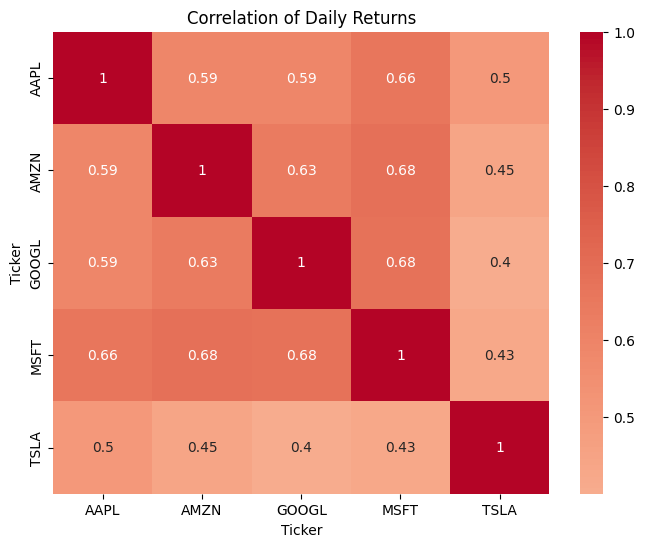

In [6]:

import seaborn as sns

# Correlation of daily returns
corr = daily_returns.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation of Daily Returns")
plt.show()


In [7]:

TARGET_TICKER = 'AAPL'  # you can change if you want another stock as target

# Work only with target stock's prices
target_prices = prices[[TARGET_TICKER]].rename(columns={TARGET_TICKER: 'price'})

# Calculate daily returns
returns = target_prices['price'].pct_change()

# Build feature dataframe
df = pd.DataFrame(index=target_prices.index)
df['price'] = target_prices['price']
df['return'] = returns

# Lagged returns
df['ret_lag1'] = returns.shift(1)
df['ret_lag5'] = returns.shift(5)
df['ret_lag10'] = returns.shift(10)

# Moving averages (relative distance)
for w in [5, 10, 20]:
    df[f'sma_{w}'] = df['price'].rolling(w).mean() / df['price'] - 1

# Rolling volatility
df['vol_10'] = returns.rolling(10).std()

# Target variable: Next-day direction (1 = Up, 0 = Down)
df['y'] = (returns.shift(-1) > 0).astype(int)

# Drop missing rows caused by lag/rolling
df = df.dropna()

print("Features created:")
print(df.head())


Features created:
                 price    return  ret_lag1  ret_lag5  ret_lag10     sma_5  \
Date                                                                        
2020-10-02  109.936562 -0.032280  0.008462  0.037516  -0.031720  0.016935   
2020-10-05  113.321625  0.030791 -0.032280  0.023869   0.030326 -0.010798   
2020-10-06  110.072754 -0.028669  0.030791 -0.007568   0.015716  0.016755   
2020-10-07  111.940369  0.016967 -0.028669  0.015076  -0.041946 -0.001477   
2020-10-08  111.833374 -0.000956  0.016967  0.008462   0.010269 -0.003688   

              sma_10    sma_20    vol_10  y  
Date                                         
2020-10-02 -0.005327  0.000257  0.025935  1  
2020-10-05 -0.029528 -0.031537  0.025984  0  
2020-10-06  0.000309 -0.002801  0.027861  1  
2020-10-07 -0.009463 -0.020412  0.023534  0  
2020-10-08 -0.002644 -0.018831  0.023652  1  


In [8]:

split_index = int(len(df) * 0.8)
X = df.drop(columns=['y'])
y = df['y']

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print("Train size:", X_train.shape, " Test size:", X_test.shape)


Train size: (988, 9)  Test size: (248, 9)


In [9]:

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Logistic Regression (with scaling)
log_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

# Random Forest
rf = RandomForestClassifier(n_estimators=300, random_state=42)

# Train both models
log_reg.fit(X_train, y_train)
rf.fit(X_train, y_train)

# Predictions
y_pred_lr = log_reg.predict(X_test)
y_pred_rf = rf.predict(X_test)

# Evaluation function
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n=== {model_name} ===")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))
    print("\nClassification Report:\n", classification_report(y_true, y_pred))

# Evaluate both models
evaluate_model(y_test, y_pred_lr, "Logistic Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest")



=== Logistic Regression ===
Accuracy : 0.5725806451612904
Precision: 0.5601851851851852
Recall   : 0.9166666666666666
F1 Score : 0.6954022988505747

Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.18      0.28       116
           1       0.56      0.92      0.70       132

    accuracy                           0.57       248
   macro avg       0.61      0.55      0.49       248
weighted avg       0.61      0.57      0.50       248


=== Random Forest ===
Accuracy : 0.5080645161290323
Precision: 0.53125
Recall   : 0.6439393939393939
F1 Score : 0.5821917808219178

Classification Report:
               precision    recall  f1-score   support

           0       0.47      0.35      0.40       116
           1       0.53      0.64      0.58       132

    accuracy                           0.51       248
   macro avg       0.50      0.50      0.49       248
weighted avg       0.50      0.51      0.50       248



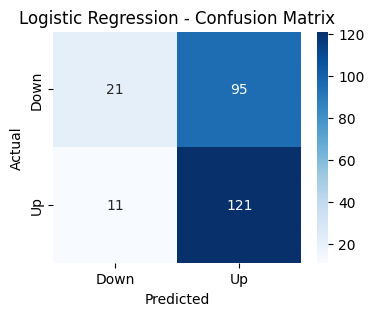

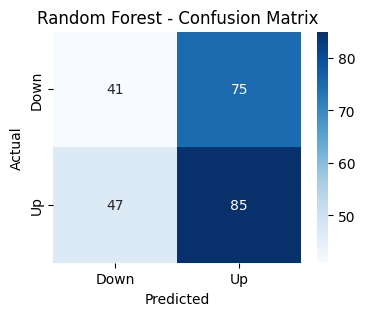

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion Matrix function
def plot_confusion(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=['Down','Up'], yticklabels=['Down','Up'])
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Plot for both models
plot_confusion(y_test, y_pred_lr, "Logistic Regression")
plot_confusion(y_test, y_pred_rf, "Random Forest")


## 📝 Conclusion
In this project, I worked with five years of stock price data for Apple, Amazon, Google, Microsoft, and Tesla. The main question I tried to answer was:

Can we use past stock movements to predict whether tomorrow’s return will be positive or negative?

I started by collecting the stock data using the yfinance library and then explored it by calculating daily, weekly, and monthly returns.I also looked at correlations to see which stocks tend to move together.After that,I created new features such as lagged returns, moving averages, and volatility, which could carry signals about future price direction.

For the prediction task, I trained two models,Logistic Regression and Random Forest. Logistic Regression performed a little better, with about 57% accuracy, mainly because it was good at catching “Up” days. Random Forest was less effective, staying close to random guessing.

In the end, the results showed how difficult it is to predict stock prices with simple historical features, since financial markets are highly noisy and unpredictable. Still, this project gave me hands-on experience in the full process: from collecting and preparing data to building models and evaluating their performance.
In this case study, I explored stock price data for five major companies over the past five years.  
By analyzing daily, weekly, and monthly returns, I observed that Tesla is much more volatile and less correlated with other large tech companies like Apple, Microsoft, Amazon, and Google.  

I then built two predictive models to forecast next-day stock movements. Logistic Regression performed slightly better, correctly capturing most upward moves, while Random Forest struggled to find meaningful patterns. However, both models showed that predicting stock direction with simple historical features is very challenging due to the noisy and unpredictable nature of financial markets.  

This project helped me understand how to collect, process, and analyze financial data, and it highlighted the limitations of basic models in real-world forecasting. Overall, the exercise provided a practical foundation for applying data mining techniques in finance.


**Financial Data Collection:**
* Please collect five-year stock price data of at least 5 stocks. You can choose any stocks you'd like to analyze.
* You have multiple ways of collecting financial data with Python, here is a reference: https://www.alpharithms.com/python-financial-data-491110/
* Load the data you collect and start working on your idea.


# Problem: pick a data science problem that you plan to solve using Stock Price Data
* The problem should be important and interesting, which has a potential impact in some area.
* The problem should be solvable using the data available and data science solutions.

Please briefly describe in the following cell: what problem are you trying to solve? why this problem is important and interesting?

# Data Collection/Processing:

In [ ]:
#----------------------------------------------
# Your code starts here
#   Please add comments or text cells in between to explain the general idea of each block of the code.
#   Please feel free to add more cells below this cell if necessary





# Data Exploration: Exploring the Dataset

**Plot the daily, weekly and monthly returns of a set of stocks of your choice**
* references:
    * https://www.investopedia.com/terms/y/yearly-rate-of-return-method.asp
    * https://www.fool.com/knowledge-center/how-to-calculate-a-monthly-return-on-investment/#:~:text=Take%20the%20ending%20balance%2C%20and,corresponds%20to%20your%20monthly%20return.
    * https://www.investopedia.com/terms/i/intraday-return.asp#:~:text=How%20Is%20Daily%20Return%20Calculated,price%2C%20then%20multiply%20by%20100.


In [ ]:
# Your code starts here
#   Please add comments or text cells in between to explain the general idea of each block of the code.
#   Please feel free to add more cells below this cell if necessary






**Other data explorations you would like to present:**

In [ ]:
# Your code starts here
#   Please add comments or text cells in between to explain the general idea of each block of the code.
#   Please feel free to add more cells below this cell if necessary






# The Solution: implement a data science solution to the problem you are trying to solve.

**Briefly describe the idea of your solutions to the problem in the following cell (you should use at least 2 methods/models to solve the problem, and compare the performance. Feel free to use any machine learning models or statistical models.):**

**Write codes to implement the solution in python:**

In [ ]:
# Your code starts here
#   Please add comments or text cells in between to explain the general idea of each block of the code.
#   Please feel free to add more cells below this cell if necessary









# Results: summarize and visualize the results discovered from the analysis

**Summarize the results of different models. Compare the perfomance and explain it. Please use figures or tables to present the results.**


In [ ]:
# Your code starts here
#   Please add comments or text cells in between to explain the general idea of each block of the code.
#   Please feel free to add more cells below this cell if necessary









# Done

All set!

**What do you need to submit?**

* **Notebook File**: Save this Jupyter notebook, and submit it in BrightSpace. This is the file you need to submit. Please make sure all the plotted tables and figures are in the notebook.


**How to submit:**
* Please submit through BrightSpace, in the Assignment "Case Study 1".
        
        
